In [7]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16,MobileNetV2
from sklearn.metrics import confusion_matrix, classification_report

In [8]:
image_size=224
batch_size = 16

In [9]:
df=tf.keras.preprocessing.image_dataset_from_directory(
     "braintumor/Training",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(image_size, image_size),
    batch_size=batch_size
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "braintumor/Training",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(image_size, image_size),
    batch_size=batch_size
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "braintumor/Testing",
    shuffle=False,
    image_size=(image_size, image_size),
    batch_size=batch_size
)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.


In [10]:
class_names = df.class_names
class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

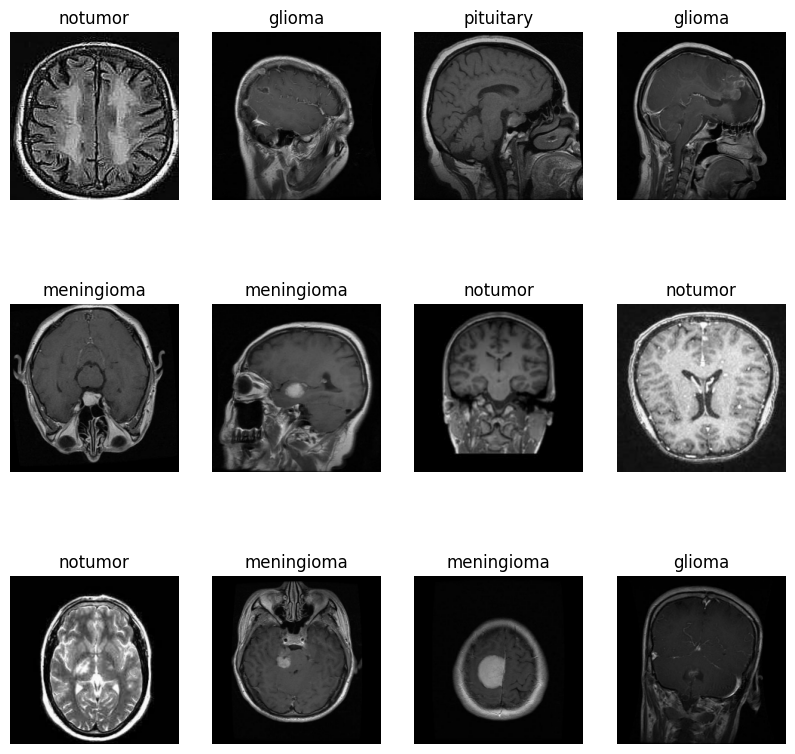

In [11]:
plt.figure(figsize=(10,10))
for images_batch,label_batch in df.take(1):
    for i in range(12):
        plt.subplot(3,4,i+1)
        plt.imshow(images_batch[i].numpy().astype('uint8'))
        plt.axis('off')
        plt.title(class_names[label_batch[i]])
    plt.show()

In [12]:
train_ds = df.cache().shuffle(10000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_dataset.cache().shuffle(10000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_dataset.cache().shuffle(10000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [13]:
print(len(train_ds), len(val_ds), len(test_ds))

280 70 100


In [14]:
reshape_resizing = tf.keras.Sequential([
    layers.Resizing(image_size,image_size),
    layers.Rescaling(1.0/255)
])

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2)
])

In [16]:
input_shape=(image_size,image_size,3)
no_classes =len(class_names)

model =models.Sequential([
    layers.Input(shape=input_shape),
    reshape_resizing,
    data_augmentation,
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(256,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation = 'relu'),
    layers.Dropout(0.2),
    layers.Dense(64,activation= 'relu'),
    layers.Dense(no_classes,activation='softmax')
    ])
    

In [11]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 173056)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      22,151,296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,530,628 (85.95 MB)

 Trainable params: 22,530,628 (85.95 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),metrics=['accuracy'])

In [17]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

In [14]:
history = model.fit(train_ds,
                    batch_size=batch_size,
                    epochs =15,
                    validation_data=val_ds,
                    verbose=1,
                    callbacks=[early_stopping]
                   )

Epoch 1/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 710s 2s/step - accuracy: 0.5585 - loss: 1.0337 - val_accuracy: 0.6330 - val_loss: 0.8490
Epoch 2/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 843s 3s/step - accuracy: 0.6946 - loss: 0.7607 - val_accuracy: 0.7259 - val_loss: 0.6374
Epoch 3/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 834s 3s/step - accuracy: 0.7319 - loss: 0.6581 - val_accuracy: 0.8027 - val_loss: 0.5402
Epoch 4/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 702s 3s/step - accuracy: 0.7703 - loss: 0.5717 - val_accuracy: 0.7777 - val_loss: 0.5126
Epoch 5/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 688s 2s/step - accuracy: 0.7891 - loss: 0.5363 - val_accuracy: 0.7598 - val_loss: 0.5687
Epoch 6/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 684s 2s/step - accuracy: 0.8156 - loss: 0.4756 - val_accuracy: 0.8509 - val_loss: 0.4103
Epoch 7/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 686s 2s/step - accuracy: 0.8304 - loss: 0.4404 - val_accuracy: 0.8393 - val_loss: 0.4328
Epoch 8/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 671s 2s/step - accuracy: 0.8406 - loss: 0.4172 - val_accu

In [15]:
loss ,accuracy = model.evaluate(test_ds,verbose=1)

100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 314ms/step - accuracy: 0.8169 - loss: 0.8333


First image to Predict
first images actual label: meningioma
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
First images predicted label: meningioma


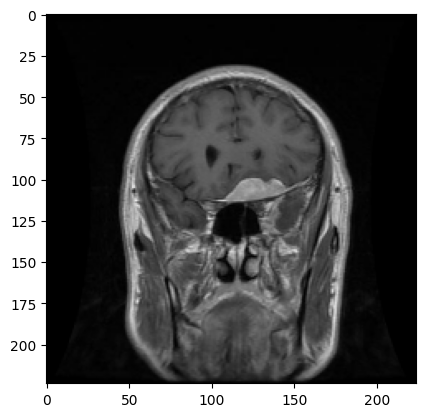

In [16]:
for images_batch,labels_batch in train_ds.take(1):
    first_image=images_batch[0].numpy().astype('uint8')
    first_label=labels_batch[0].numpy()

    print('First image to Predict')
    plt.imshow(first_image)
    print("first images actual label:",class_names[first_label])
    batch_prediction=model.predict(images_batch)
    print('First images predicted label:',class_names[np.argmax(batch_prediction[0])])

In [17]:
def predict(model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array=tf.expand_dims(img_array,0)

    predictions=model.predict(img_array)
    predicted_class=class_names[np.argmax(predictions[0])]
    confidence=round(100*(np.max(predictions[0])),2)
    return predicted_class,confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


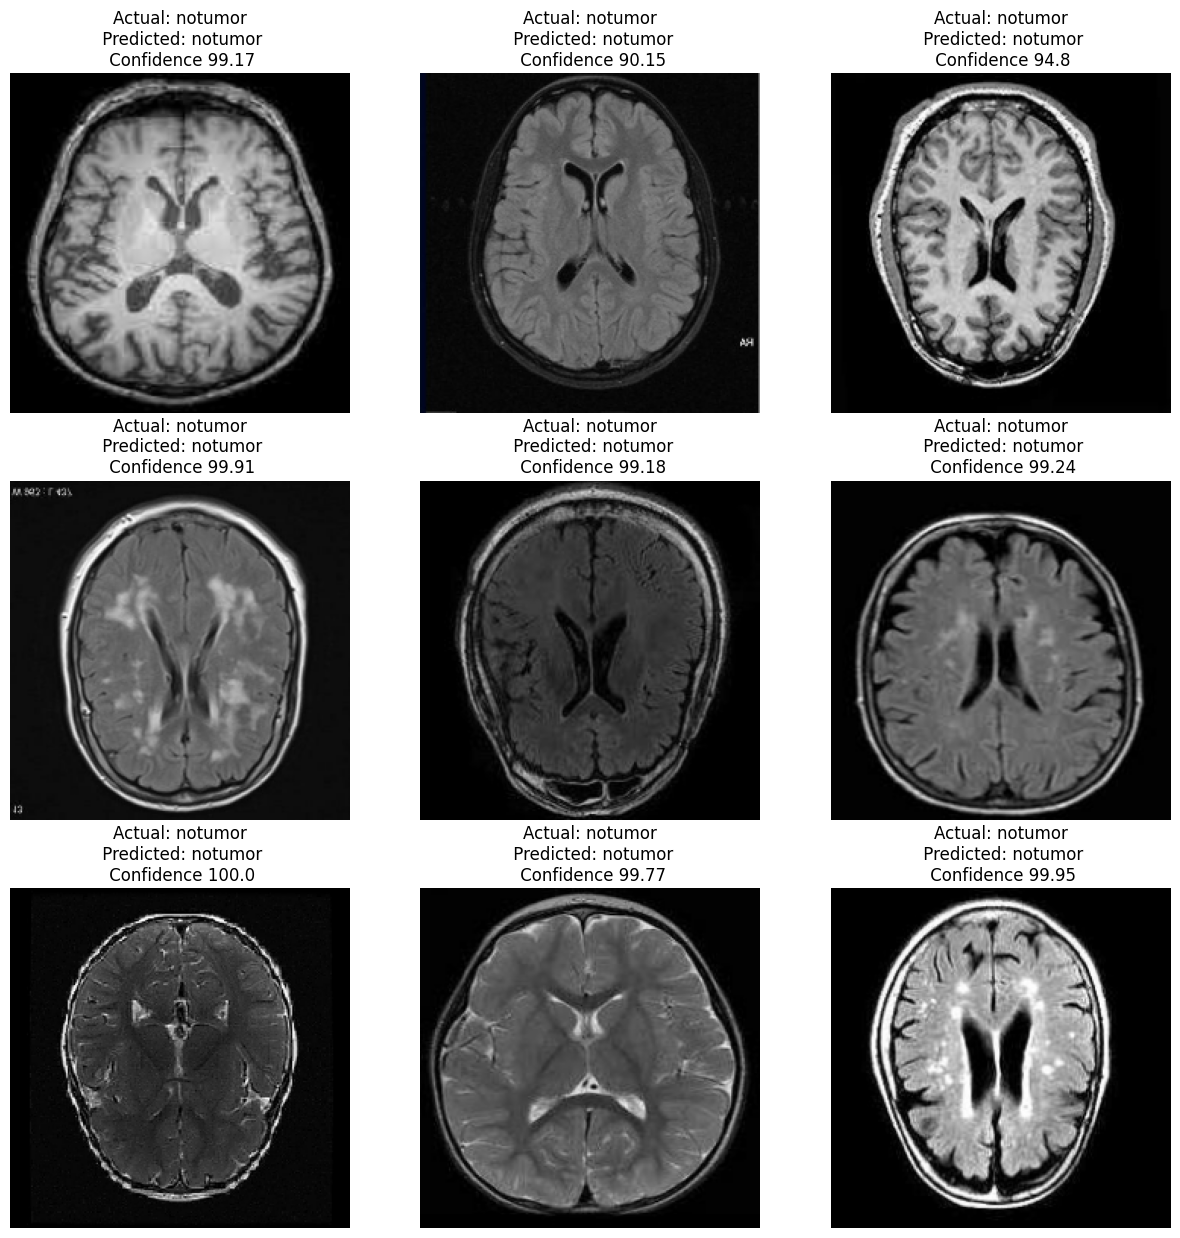

In [22]:
plt.figure(figsize=(15,15))
for images,labels in test_ds.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        predicted_class,confidence=predict(model,images[i].numpy())
        actual_class=class_names[labels[i]]
        plt.title(f"Actual: {actual_class}\n Predicted: {predicted_class}\n Confidence {confidence}")
        plt.axis('off')

In [21]:
model.save('my_model.h5')

In [19]:
model = tf.keras.models.load_model('my_model.h5')

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
y_true = []
y_pred = []
for images, labels in test_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 562ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [12]:
VGG16_model = VGG16(weights='imagenet',
                    include_top= False,
                    input_shape=(image_size, image_size, 3))


In [13]:
VGG16_model.trainable=False

In [14]:
from tensorflow.keras import layers, models

version_1 = models.Sequential([
    layers.Input(shape=input_shape),
    reshape_resizing,
    data_augmentation,
    VGG16_model,

    layers.Flatten(),

    layers.Dense(4608, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(1152, activation='relu'),

    layers.Dense(no_classes, activation='softmax')
])

In [15]:
version_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4608)                │     115,610,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1152)                │       5,309,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │           4,612 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 135,638,980 (517.42 MB)

 Trainable params: 120,924,292 (461.29 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [16]:
version_1.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),metrics=['accuracy'])

In [17]:
history_2= version_1.fit(train_ds,
                          batch_size=batch_size,
                    epochs =10,
                    validation_data=val_ds,
                    verbose=1,
                    callbacks=[early_stopping]
                   )

Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1634s 6s/step - accuracy: 0.7254 - loss: 1.3248 - val_accuracy: 0.7795 - val_loss: 0.6114
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1513s 5s/step - accuracy: 0.8283 - loss: 0.4654 - val_accuracy: 0.8902 - val_loss: 0.3090
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1456s 5s/step - accuracy: 0.8373 - loss: 0.4320 - val_accuracy: 0.8500 - val_loss: 0.3856
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1406s 5s/step - accuracy: 0.8554 - loss: 0.3867 - val_accuracy: 0.8929 - val_loss: 0.3341
Epoch 5/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1424s 5s/step - accuracy: 0.8580 - loss: 0.3889 - val_accuracy: 0.8902 - val_loss: 0.3106
Epoch 6/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1617s 6s/step - accuracy: 0.8694 - loss: 0.3550 - val_accuracy: 0.8866 - val_loss: 0.3111
Epoch 7/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1361s 5s/step - accuracy: 0.8746 - loss: 0.3352 - val_accuracy: 0.9000 - val_loss: 0.2829
Epoch 8/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 1827s 7s/step - accuracy: 0.8783 - loss: 0.3376 - 

In [20]:
loss1 ,accuracy1 = version_1.evaluate(test_ds,verbose=1)

100/100 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.8394 - loss: 0.6750


In [21]:
version_1.save('VGG16_model.keras')

In [20]:
Vg_model = tf.keras.models.load_model('VGG16_model.keras')

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
y_true = []
y_pred = []
for images, labels in test_dataset:
    preds = Vg_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

In [31]:
def predict(model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array=tf.expand_dims(img_array,0)

    predictions=model.predict(img_array)
    predicted_class=class_names[np.argmax(predictions[0])]
    confidence=round(100*(np.max(predictions[0])),2)
    return predicted_class,confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 595ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 500ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step


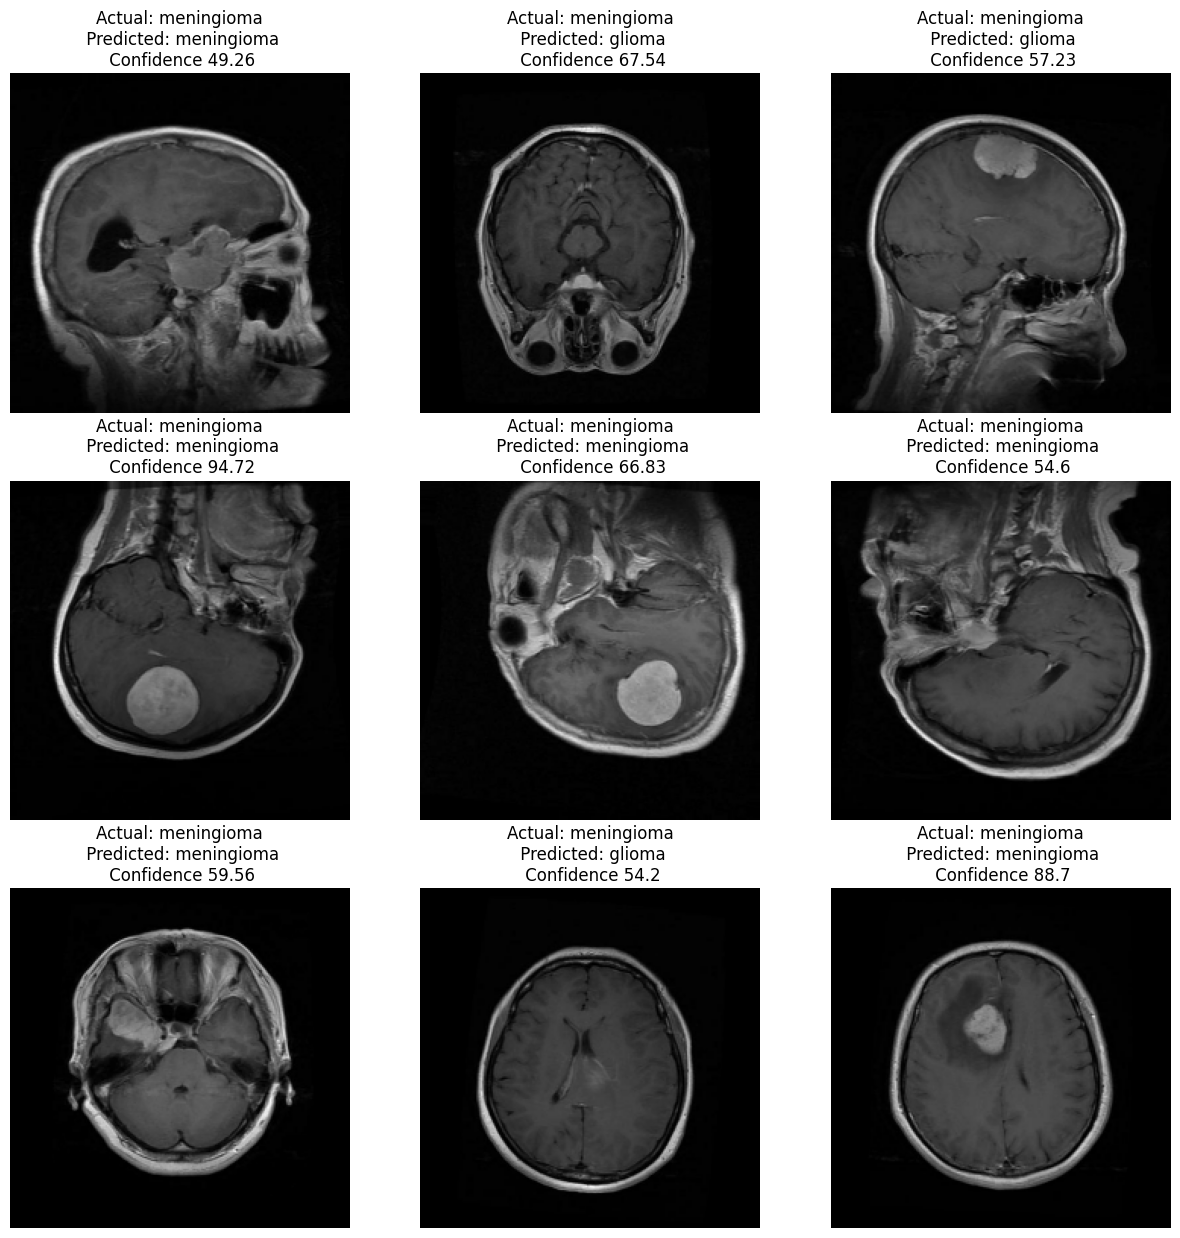

In [33]:
plt.figure(figsize=(15,15))
for images,labels in test_ds.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        predicted_class,confidence=predict(Vg_model,images[i].numpy())
        actual_class=class_names[labels[i]]
        plt.title(f"Actual: {actual_class}\n Predicted: {predicted_class}\n Confidence {confidence}")
        plt.axis('off')

In [21]:
mobile = MobileNetV2(weights='imagenet',
                     include_top= False,
                     input_shape= (image_size,image_size ,3)
                    )

In [22]:
mobile.trainable = False

In [23]:
from tensorflow.keras import layers, models
mobile_model = models.Sequential([
    layers.Input(shape=input_shape),
    reshape_resizing,
    data_augmentation,
    mobile,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(no_classes, activation='softmax')
])

In [24]:
mobile_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
mobile_model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),metrics=['accuracy'])

In [ ]:
history3=mobile_model.fit(train_ds,
                          batch_size=batch_size,
                          epochs =10,
                          validation_data=val_ds,
                          verbose=1,
                          callbacks=[early_stopping]
                         )

Epoch 1/10
 41/280 ━━━━━━━━━━━━━━━━━━━━ 3:42 929ms/step - accuracy: 0.5352 - loss: 1.0980

In [ ]:
loss2,accu2 =mobile_model.evaluate(test_ds,verbose=1)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
y_true = []
y_pred = []
for images, labels in test_dataset:
    preds = mobile_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

In [ ]:
def predict(model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array=tf.expand_dims(img_array,0)

    predictions=model.predict(img_array)
    predicted_class=class_names[np.argmax(predictions[0])]
    confidence=round(100*(np.max(predictions[0])),2)
    return predicted_class,confidence

In [ ]:
plt.figure(figsize=(15,15))
for images,labels in test_ds.take(3):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        predicted_class,confidence=predict(mobile_model,images[i].numpy())
        actual_class=class_names[labels[i]]
        plt.title(f"Actual: {actual_class}\n Predicted: {predicted_class}\n Confidence {confidence}")
        plt.axis('off')

In [ ]:
mobile_model.save('mobile_model.keras')